
当前拟合区间大小 (Bin Size) = 2.0 Å


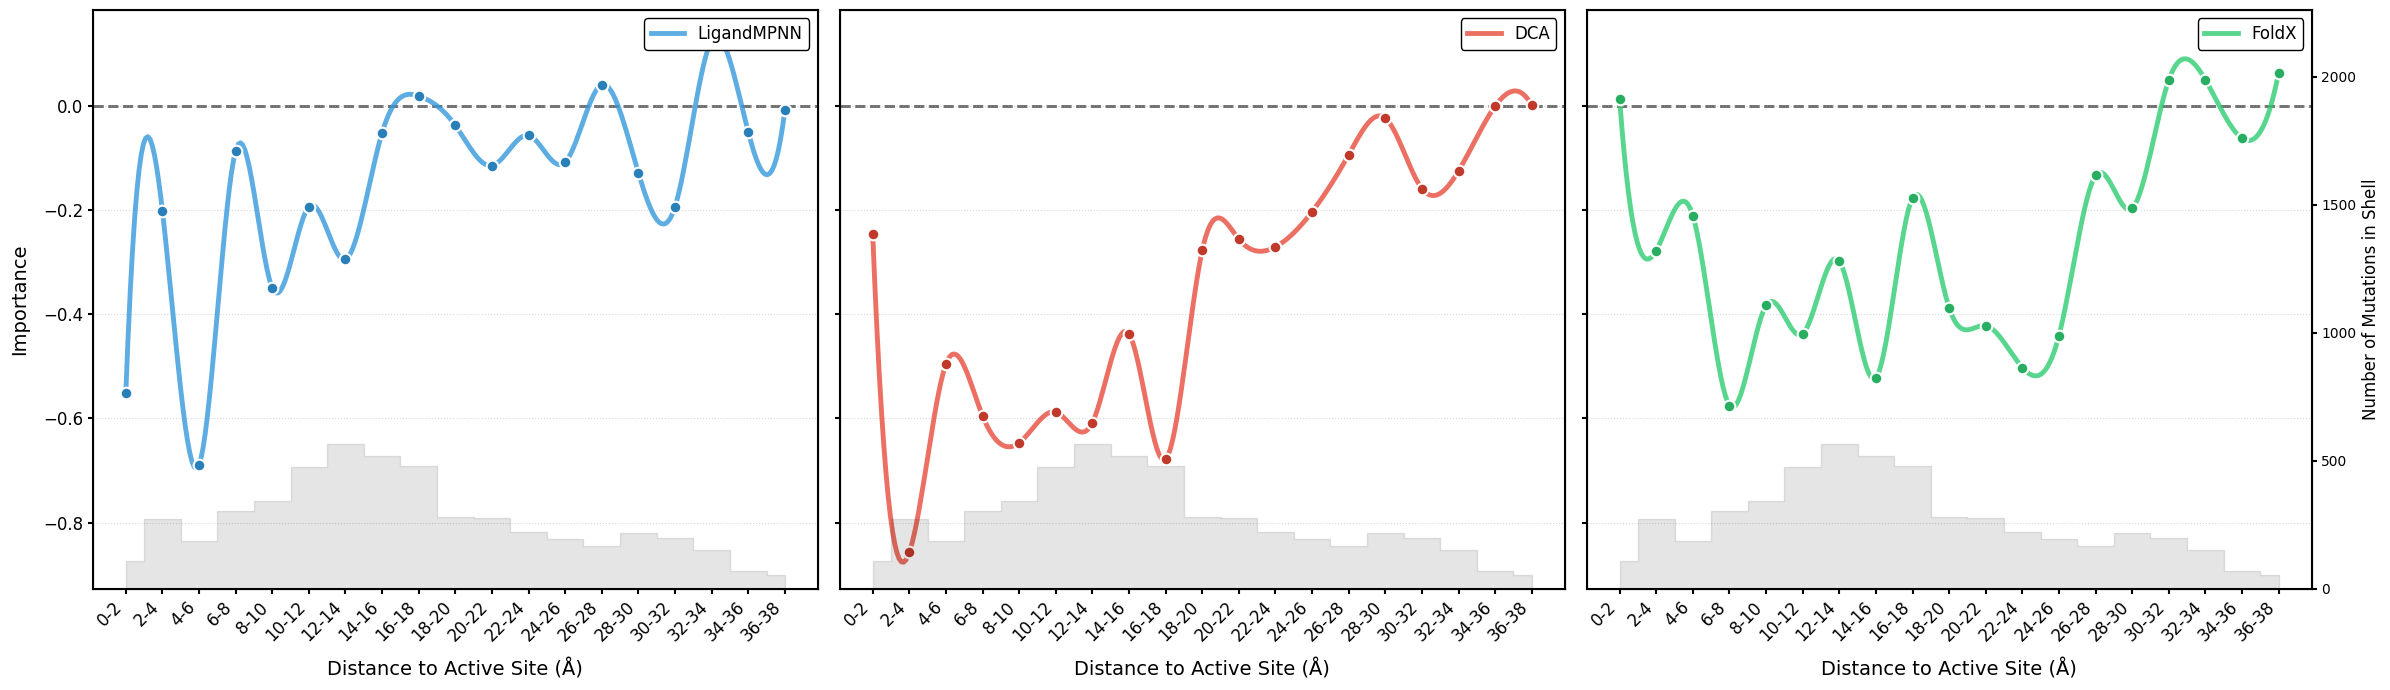

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import make_interp_spline
from scipy.stats import spearmanr
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

TRAIN_CSV_PATH = "/share/home/wangtb/enzyme_shell/data/activity/3_PTEN.csv"
SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']
TARGET = 'Cum_score'

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

df_pten = pd.read_csv(TRAIN_CSV_PATH).dropna(subset=SCORES + ['Distance_to_Active_Site', TARGET])
df_pten = filter_single_mutations(df_pten)
for col in SCORES + ['Distance_to_Active_Site']:
    df_pten[col] = df_pten[col].astype(float)

def plot_decay_trend(df, bin_size=1.0):
    print(f"\n当前拟合区间大小 (Bin Size) = {bin_size} Å")
    df_work = df.copy()

    max_dist = np.ceil(df_work['Distance_to_Active_Site'].max())
    bins = np.arange(0, max_dist + bin_size, bin_size)
    
    if isinstance(bin_size, int) or bin_size.is_integer():
        labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
    else:
        labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]

    df_work['Distance_Shell'] = pd.cut(df_work['Distance_to_Active_Site'], bins=bins, labels=labels, include_lowest=True)

    shell_results = []
    min_samples_threshold = 2

    for i, shell in enumerate(labels):
        df_shell = df_work[df_work['Distance_Shell'] == shell]
        
        if len(df_shell) < min_samples_threshold: 
            continue
            
        X = df_shell[SCORES].values
        y = df_shell[TARGET].values
        
        try:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            model = Ridge(alpha=1.0)
            model.fit(X_scaled, y)
            
            res = {'Distance_Shell': shell, 'Sample_Size': len(df_shell)}
            for j, score_name in enumerate(SCORES):
                res[f'{score_name}_Impact'] = model.coef_[j] 
                
            shell_results.append(res)
        except:
            continue

    if not shell_results:
        print("有效数据点不足，无法拟合趋势。")
        return

    df_res = pd.DataFrame(shell_results)

    fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

    x_pos = np.arange(len(df_res))
    x_dense = np.linspace(x_pos.min(), x_pos.max(), 300)
    k_spline = 3 if len(x_pos) > 3 else 1

    configs = [
        ('LigandMPNN_score', '#3498db', '#2980b9', 'LigandMPNN'),
        ('DCA_score', '#e74c3c', '#c0392b', 'DCA'),
        ('FoldX_ddG', '#2ecc71', '#27ae60', 'FoldX')
    ]

    for ax, (score_name, line_color, point_color, label_name) in zip(axes, configs):
        impact_data = df_res[f'{score_name}_Impact']
        
        spl = make_interp_spline(x_pos, impact_data, k=k_spline)
        y_smooth = spl(x_dense)

        ax.plot(x_dense, y_smooth, color=line_color, linewidth=3.5, label=label_name, alpha=0.8)
        ax.scatter(x_pos, impact_data, color=point_color, s=70, edgecolor='white', linewidth=1.5, zorder=5)

        ax.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.6, zorder=1)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(df_res['Distance_Shell'], fontsize=10, rotation=45, ha='right', color='black')
        ax.tick_params(axis='both', labelsize=12, colors='black', width=1.5)
        ax.set_xlabel('Distance to Active Site (Å)', fontsize=14, labelpad=10, color='black')
        
        if ax == axes[0]:
            ax.set_ylabel('Importance', fontsize=14, labelpad=10, color='black')
        
        ax.legend(fontsize=12, edgecolor='black', framealpha=1, loc='upper right')
        ax.grid(axis='y', linestyle=':', alpha=0.5)

        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(1.5)

        ax2 = ax.twinx()
        ax2.fill_between(x_pos, 0, df_res['Sample_Size'], color='black', alpha=0.1, step='mid', zorder=0)
        ax2.set_ylim(0, df_res['Sample_Size'].max() * 4) 
        
        if ax == axes[-1]:
            ax2.set_ylabel('Number of Mutations in Shell', color='black', fontsize=12)
            ax2.tick_params(axis='y', labelcolor='black', colors='black', width=1.5)
        else:
            ax2.tick_params(axis='y', which='both', right=False, labelright=False)

    plt.tight_layout()
    plt.show()

BIN_SIZE = 2.0
plot_decay_trend(df_pten, bin_size=BIN_SIZE)

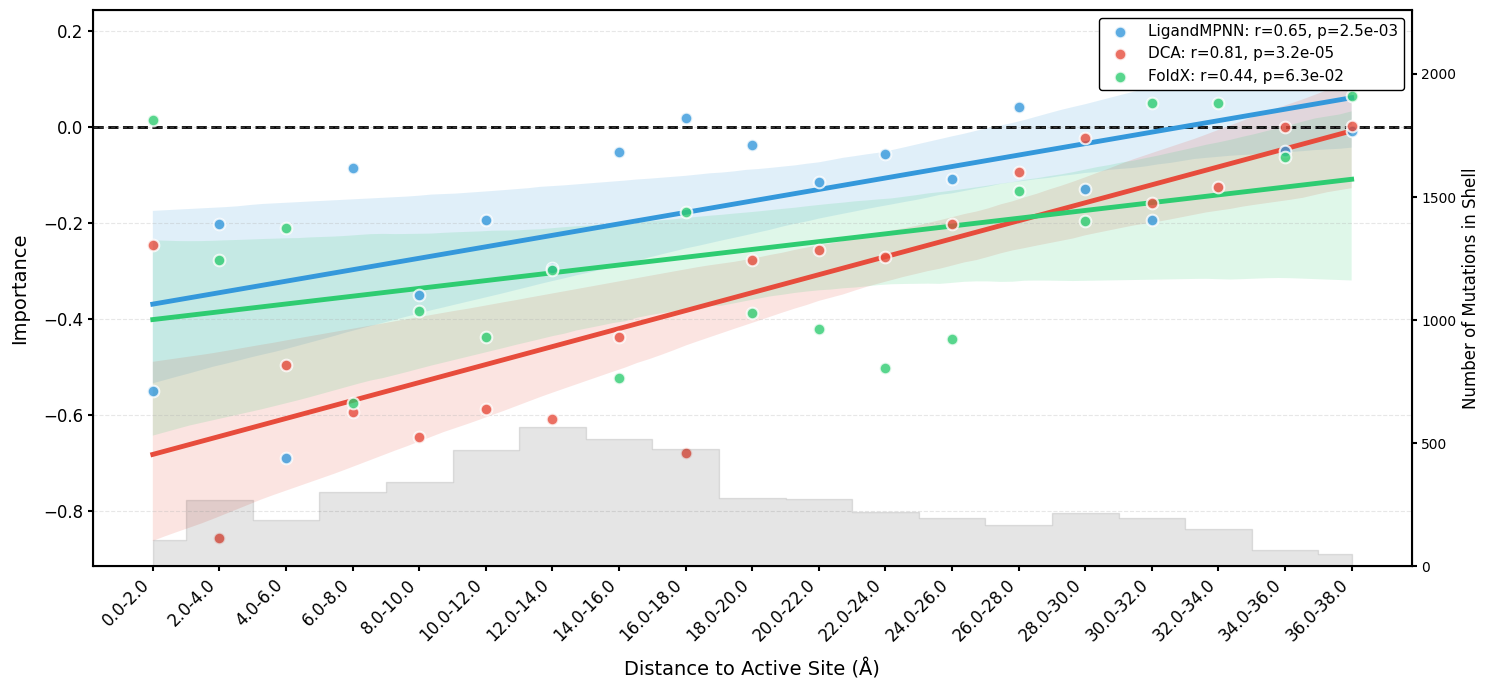

In [4]:
def plot_decay_trend_signed(df, bin_size=1.5):
    df_work = df.copy()

    max_dist = np.ceil(df_work['Distance_to_Active_Site'].max())
    bins = np.arange(0, max_dist + bin_size, bin_size)
    labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]
    df_work['Distance_Shell'] = pd.cut(df_work['Distance_to_Active_Site'], bins=bins, labels=labels, include_lowest=True)

    shell_results = []
    min_samples_threshold = 2

    for i, shell in enumerate(labels):
        df_shell = df_work[df_work['Distance_Shell'] == shell]
        if len(df_shell) < min_samples_threshold: continue
            
        X = df_shell[SCORES].values
        y = df_shell[TARGET].values
        
        try:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            model = Ridge(alpha=1.0)
            model.fit(X_scaled, y)
            
            center_d = bins[i] + bin_size / 2.0
            res = {'Distance_Shell': shell, 'Distance_Center': center_d, 'Sample_Size': len(df_shell)}
            for j, score_name in enumerate(SCORES):
                res[f'{score_name}_Impact'] = model.coef_[j] 
            shell_results.append(res)
        except:
            continue

    if not shell_results: return
    df_res = pd.DataFrame(shell_results)

    fig, ax = plt.subplots(figsize=(15, 7))

    plot_map = {
        'LigandMPNN_score': ('#3498db', 'LigandMPNN'),
        'DCA_score': ('#e74c3c', 'DCA'),
        'FoldX_ddG': ('#2ecc71', 'FoldX')
    }

    for score_col, (color, label_name) in plot_map.items():
        impact_col = f'{score_col}_Impact'
        
        rho, p_val = spearmanr(df_res['Distance_Center'], df_res[impact_col])

        legend_label = f"{label_name}: r={rho:.2f}, p={p_val:.1e}"
        
        sns.regplot(
            x='Distance_Center', y=impact_col, data=df_res, 
            ax=ax, color=color, label=legend_label,
            scatter_kws={'s': 70, 'edgecolors': 'white', 'linewidths': 1.5, 'zorder': 5}, 
            line_kws={'linewidth': 3.5, 'zorder': 4}
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=2, zorder=1)

    ax.set_xticks(df_res['Distance_Center'])
    ax.set_xticklabels(df_res['Distance_Shell'], fontsize=10, rotation=45, ha='right', color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black', width=1.5)
    
    ax.set_xlabel('Distance to Active Site (Å)', fontsize=14, labelpad=10, color='black')
    ax.set_ylabel('Importance', fontsize=14, labelpad=10, color='black')
    
    ax.legend(fontsize=11, edgecolor='black', framealpha=1, loc='upper right')

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.5)

    ax2 = ax.twinx()
    ax2.fill_between(df_res['Distance_Center'], 0, df_res['Sample_Size'], color='black', alpha=0.1, step='mid', zorder=1)
    ax2.set_ylabel('Number of Mutations in Shell', color='black', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='black', colors='black', width=1.5)
    ax2.set_ylim(0, df_res['Sample_Size'].max() * 4) 
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

BIN_SIZE = 2.0
plot_decay_trend_signed(df_pten, bin_size=BIN_SIZE)


当前拟合区间大小 (Bin Size) = 2 Å


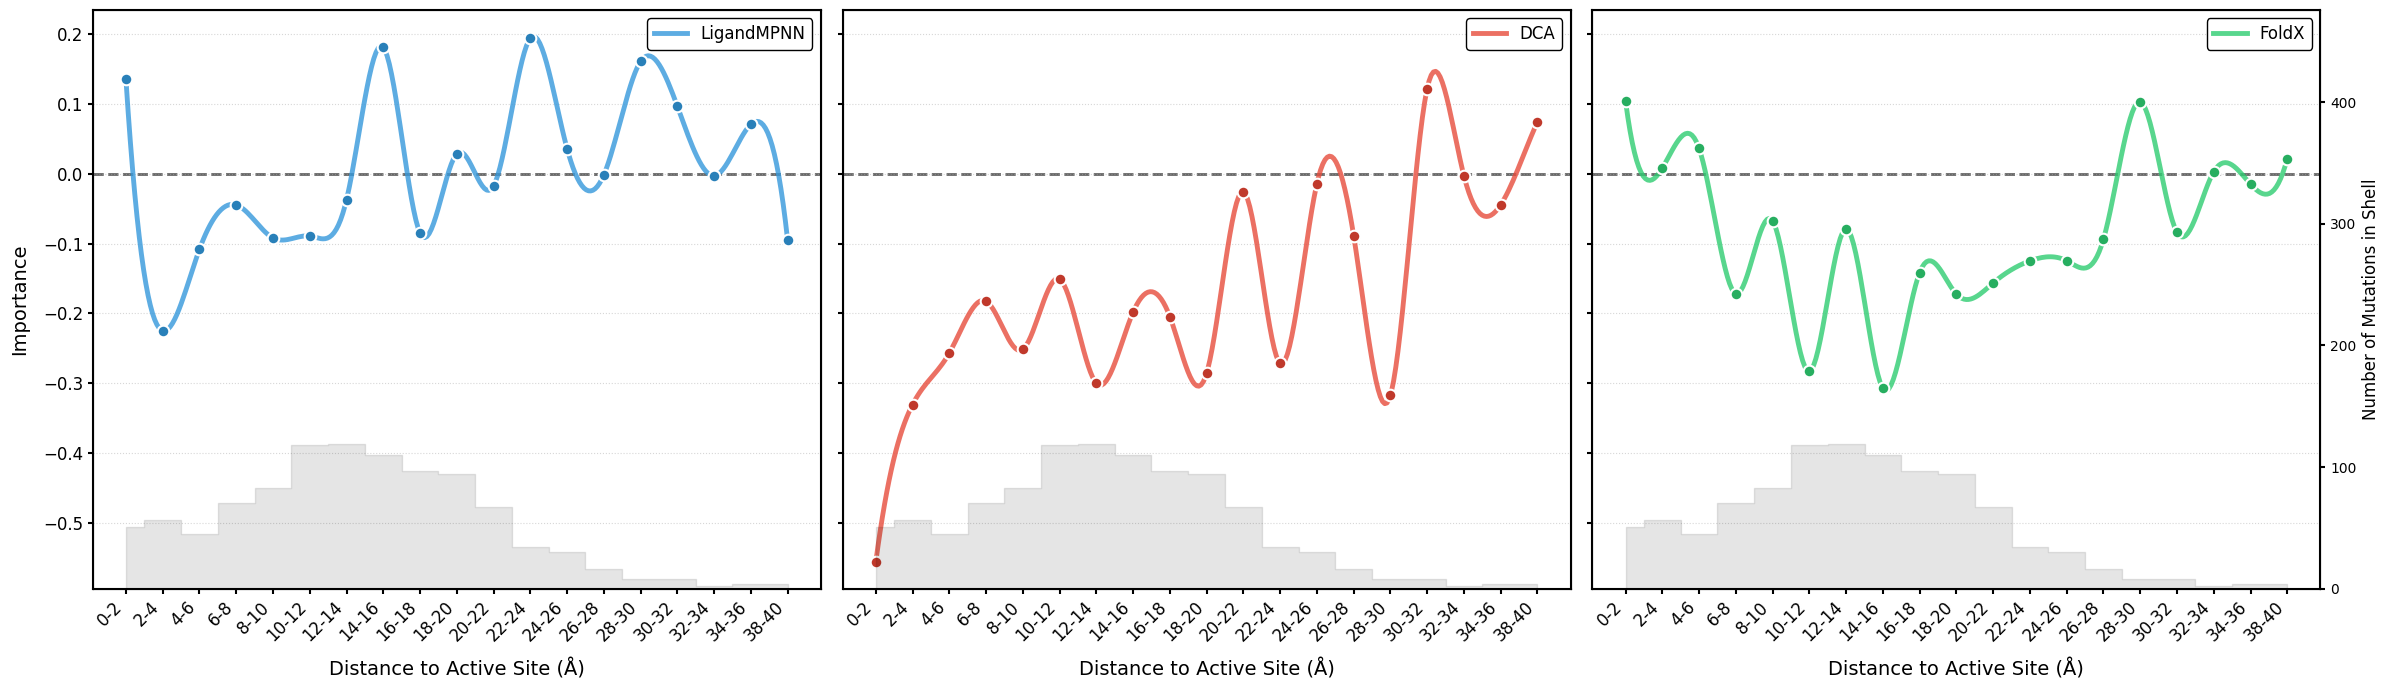

In [6]:
TRAIN_CSV_PATH = "/share/home/wangtb/enzyme_shell/data/activity/3_PAFA.csv"
SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']
TARGET = 'lg_kcat'

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

# 读取数据并计算 kcat 的对数 (lg)
df_pten = pd.read_csv(TRAIN_CSV_PATH)
df_pten['lg_kcat'] = np.log10(df_pten['kcat'])
df_pten = df_pten.dropna(subset=SCORES + ['Distance_to_Active_Site', TARGET])

df_pten = filter_single_mutations(df_pten)
for col in SCORES + ['Distance_to_Active_Site']:
    df_pten[col] = df_pten[col].astype(float)

def plot_decay_trend(df, bin_size=1.0):
    print(f"\n当前拟合区间大小 (Bin Size) = {bin_size} Å")
    df_work = df.copy()

    max_dist = np.ceil(df_work['Distance_to_Active_Site'].max())
    bins = np.arange(0, max_dist + bin_size, bin_size)
    
    if isinstance(bin_size, int) or bin_size.is_integer():
        labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
    else:
        labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]

    df_work['Distance_Shell'] = pd.cut(df_work['Distance_to_Active_Site'], bins=bins, labels=labels, include_lowest=True)

    shell_results = []
    min_samples_threshold = 2

    for i, shell in enumerate(labels):
        df_shell = df_work[df_work['Distance_Shell'] == shell]
        
        if len(df_shell) < min_samples_threshold: 
            continue
            
        X = df_shell[SCORES].values
        y = df_shell[TARGET].values
        
        try:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            
            model = Ridge(alpha=1.0)
            model.fit(X_scaled, y)
            
            res = {'Distance_Shell': shell, 'Sample_Size': len(df_shell)}
            for j, score_name in enumerate(SCORES):
                res[f'{score_name}_Impact'] = model.coef_[j] 
                
            shell_results.append(res)
        except:
            continue

    if not shell_results:
        print("有效数据点不足，无法拟合趋势。")
        return

    df_res = pd.DataFrame(shell_results)

    fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

    x_pos = np.arange(len(df_res))
    x_dense = np.linspace(x_pos.min(), x_pos.max(), 300)
    k_spline = 3 if len(x_pos) > 3 else 1

    configs = [
        ('LigandMPNN_score', '#3498db', '#2980b9', 'LigandMPNN'),
        ('DCA_score', '#e74c3c', '#c0392b', 'DCA'),
        ('FoldX_ddG', '#2ecc71', '#27ae60', 'FoldX')
    ]

    for ax, (score_name, line_color, point_color, label_name) in zip(axes, configs):
        impact_data = df_res[f'{score_name}_Impact']
        
        spl = make_interp_spline(x_pos, impact_data, k=k_spline)
        y_smooth = spl(x_dense)

        ax.plot(x_dense, y_smooth, color=line_color, linewidth=3.5, label=label_name, alpha=0.8)
        ax.scatter(x_pos, impact_data, color=point_color, s=70, edgecolor='white', linewidth=1.5, zorder=5)

        ax.axhline(0, color='black', linestyle='--', linewidth=2, alpha=0.6, zorder=1)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(df_res['Distance_Shell'], fontsize=10, rotation=45, ha='right', color='black')
        ax.tick_params(axis='both', labelsize=12, colors='black', width=1.5)
        ax.set_xlabel('Distance to Active Site (Å)', fontsize=14, labelpad=10, color='black')
        
        if ax == axes[0]:
            ax.set_ylabel('Importance', fontsize=14, labelpad=10, color='black')
        
        ax.legend(fontsize=12, edgecolor='black', framealpha=1, loc='upper right')
        ax.grid(axis='y', linestyle=':', alpha=0.5)

        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_linewidth(1.5)

        ax2 = ax.twinx()
        ax2.fill_between(x_pos, 0, df_res['Sample_Size'], color='black', alpha=0.1, step='mid', zorder=0)
        ax2.set_ylim(0, df_res['Sample_Size'].max() * 4) 
        
        if ax == axes[-1]:
            ax2.set_ylabel('Number of Mutations in Shell', color='black', fontsize=12)
            ax2.tick_params(axis='y', labelcolor='black', colors='black', width=1.5)
        else:
            ax2.tick_params(axis='y', which='both', right=False, labelright=False)

    plt.tight_layout()
    plt.show()

BIN_SIZE = 2
plot_decay_trend(df_pten, bin_size=BIN_SIZE)

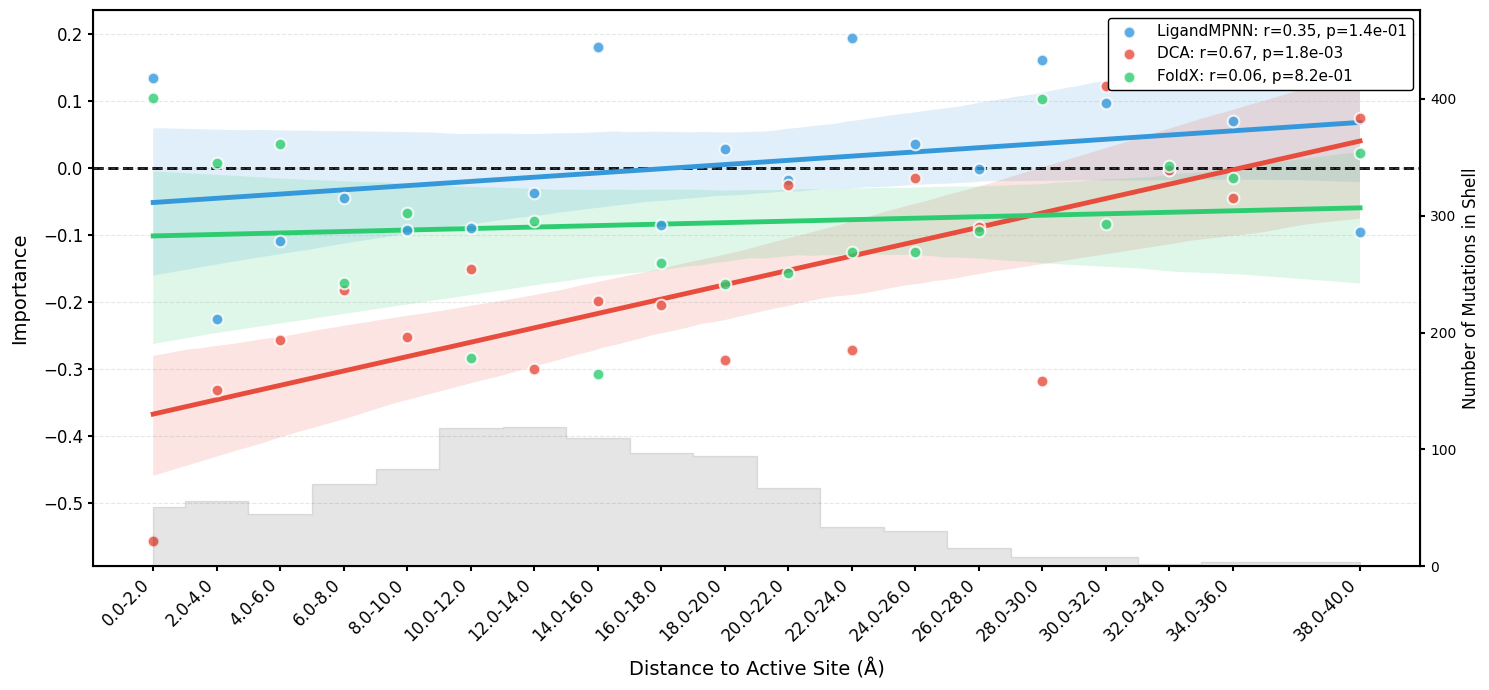

In [7]:
def plot_decay_trend_signed(df, bin_size=1.5):
    df_work = df.copy()

    max_dist = np.ceil(df_work['Distance_to_Active_Site'].max())
    bins = np.arange(0, max_dist + bin_size, bin_size)
    labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]
    df_work['Distance_Shell'] = pd.cut(df_work['Distance_to_Active_Site'], bins=bins, labels=labels, include_lowest=True)

    shell_results = []
    min_samples_threshold = 2

    for i, shell in enumerate(labels):
        df_shell = df_work[df_work['Distance_Shell'] == shell]
        if len(df_shell) < min_samples_threshold: continue
            
        X = df_shell[SCORES].values
        y = df_shell[TARGET].values
        
        try:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            model = Ridge(alpha=1.0)
            model.fit(X_scaled, y)
            
            center_d = bins[i] + bin_size / 2.0
            res = {'Distance_Shell': shell, 'Distance_Center': center_d, 'Sample_Size': len(df_shell)}
            for j, score_name in enumerate(SCORES):
                res[f'{score_name}_Impact'] = model.coef_[j] 
            shell_results.append(res)
        except:
            continue

    if not shell_results: return
    df_res = pd.DataFrame(shell_results)

    fig, ax = plt.subplots(figsize=(15, 7))

    plot_map = {
        'LigandMPNN_score': ('#3498db', 'LigandMPNN'),
        'DCA_score': ('#e74c3c', 'DCA'),
        'FoldX_ddG': ('#2ecc71', 'FoldX')
    }

    for score_col, (color, label_name) in plot_map.items():
        impact_col = f'{score_col}_Impact'
        
        rho, p_val = spearmanr(df_res['Distance_Center'], df_res[impact_col])

        legend_label = f"{label_name}: r={rho:.2f}, p={p_val:.1e}"
        
        sns.regplot(
            x='Distance_Center', y=impact_col, data=df_res, 
            ax=ax, color=color, label=legend_label,
            scatter_kws={'s': 70, 'edgecolors': 'white', 'linewidths': 1.5, 'zorder': 5}, 
            line_kws={'linewidth': 3.5, 'zorder': 4}
        )

    ax.axhline(0, color='black', linestyle='--', linewidth=2, zorder=1)

    ax.set_xticks(df_res['Distance_Center'])
    ax.set_xticklabels(df_res['Distance_Shell'], fontsize=10, rotation=45, ha='right', color='black')
    ax.tick_params(axis='both', labelsize=12, colors='black', width=1.5)
    
    ax.set_xlabel('Distance to Active Site (Å)', fontsize=14, labelpad=10, color='black')
    ax.set_ylabel('Importance', fontsize=14, labelpad=10, color='black')
    
    ax.legend(fontsize=11, edgecolor='black', framealpha=1, loc='upper right')

    ax.grid(axis='y', linestyle='--', alpha=0.3)
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.5)

    ax2 = ax.twinx()
    ax2.fill_between(df_res['Distance_Center'], 0, df_res['Sample_Size'], color='black', alpha=0.1, step='mid', zorder=1)
    ax2.set_ylabel('Number of Mutations in Shell', color='black', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='black', colors='black', width=1.5)
    ax2.set_ylim(0, df_res['Sample_Size'].max() * 4) 
    ax2.grid(False)

    plt.tight_layout()
    plt.show()

BIN_SIZE = 2
plot_decay_trend_signed(df_pten, bin_size=BIN_SIZE)

正在加载 PAFA 独立测试集数据...
PTEN 训练集 (Cum_score) : r = +0.6001, p = 0.00e+00
PTEN 测试集 (Cum_score) : r = +0.6065,  p = 1.08e-102
PAFA 独立测试集 (lg_kcat)     : r = +0.5125,  p = 4.04e-69


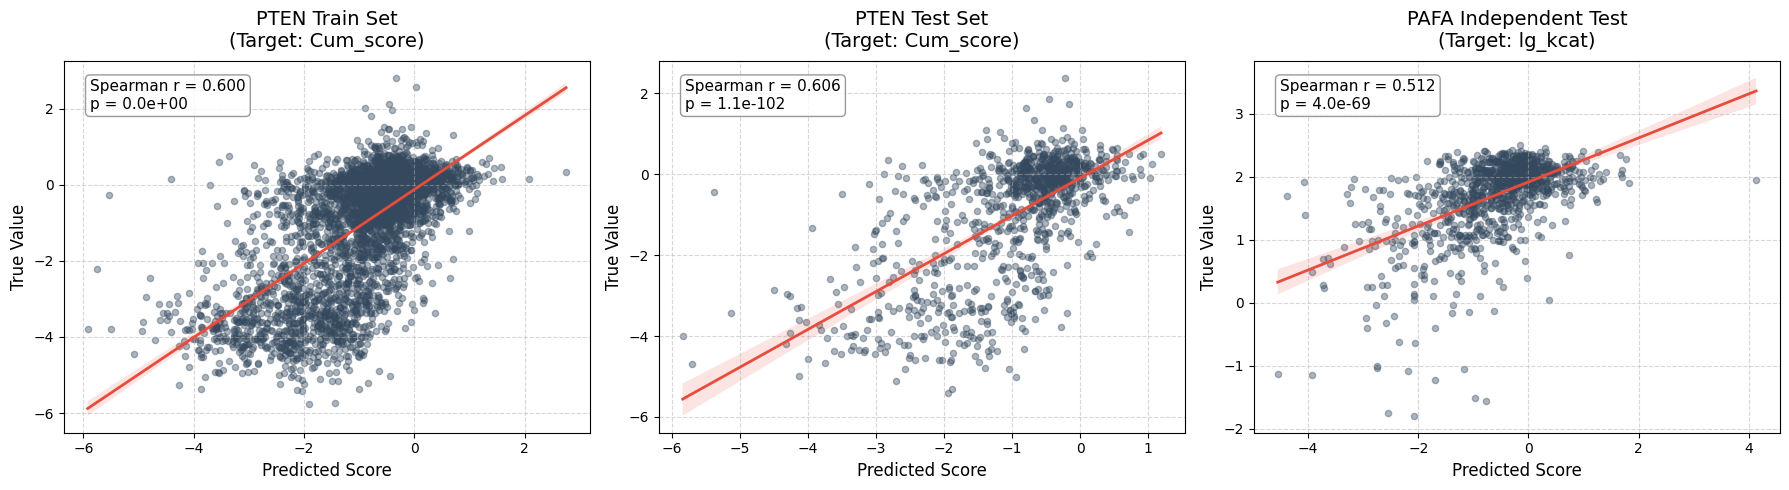


函数参数 (Parameters P):
g(d) [MPNN]  : A=-0.659, lambda=0.157, B=-0.055, omega=1.051
f(d) [DCA]   : A=-1.570, lambda=0.063, B=0.061, omega=0.683
v(d) [FoldX] : A=224.245, lambda=0.005, B=38.716, omega=0.028, phi=5.907, C=-209.733
Bias         : -0.812


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.optimize import least_squares
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

PTEN_CSV_PATH = "/share/home/wangtb/enzyme_shell/data/activity/3_PTEN.csv"
PAFA_CSV_PATH = "/share/home/wangtb/enzyme_shell/data/activity/3_PAFA.csv"

SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

df_pten = pd.read_csv(PTEN_CSV_PATH).dropna(subset=SCORES + ['Distance_to_Active_Site', 'Cum_score'])
df_pten = filter_single_mutations(df_pten)
for col in SCORES + ['Distance_to_Active_Site', 'Cum_score']:
    df_pten[col] = df_pten[col].astype(float)

pten_train, pten_test = train_test_split(df_pten, test_size=0.2, random_state=42)

print("正在加载 PAFA 独立测试集数据...")
df_pafa_raw = pd.read_csv(PAFA_CSV_PATH)
df_pafa_raw = df_pafa_raw[df_pafa_raw['kcat'] > 0]
df_pafa_raw['lg_kcat'] = np.log10(df_pafa_raw['kcat'])
df_pafa = df_pafa_raw.dropna(subset=SCORES + ['Distance_to_Active_Site', 'lg_kcat'])
df_pafa = filter_single_mutations(df_pafa)
for col in SCORES + ['Distance_to_Active_Site', 'lg_kcat']:
    df_pafa[col] = df_pafa[col].astype(float)

scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(pten_train[SCORES])
X_test  = scaler_X.transform(pten_test[SCORES])
X_pafa  = scaler_X.transform(df_pafa[SCORES])

d_train = pten_train['Distance_to_Active_Site'].values
d_test  = pten_test['Distance_to_Active_Site'].values
d_pafa  = df_pafa['Distance_to_Active_Site'].values

y_train = pten_train['Cum_score'].values
y_test  = pten_test['Cum_score'].values
y_pafa  = df_pafa['lg_kcat'].values

# Score = g(d)*MPNN + f(d)*DCA + v(d)*FoldX + Bias
# g(d) = P0 * exp(-|P1|*d) + P2 * cos(P3*d)
# f(d) = P4 * exp(-|P5|*d) + P6 * cos(P7*d)
# v(d) = P8 * exp(-|P9|*d) + P10 * sin(P11*d + P12) + P13

def predict_score(P, d, X):
    X_mpnn = X[:, 0]
    X_dca  = X[:, 1]
    X_foldx= X[:, 2]
    
    # 结构权重 (LigandMPNN)
    g_d = P[0] * np.exp(-np.abs(P[1]) * d) + P[2] * np.cos(P[3] * d)
    # 进化权重 (DCA)
    f_d = P[4] * np.exp(-np.abs(P[5]) * d) + P[6] * np.cos(P[7] * d)
    # 热力学权重 (FoldX)
    v_d = P[8] * np.exp(-np.abs(P[9]) * d) + P[10] * np.sin(P[11] * d + P[12]) + P[13]
    
    # 组合预测值 (P[14] 为全局截距)
    y_pred = g_d * X_mpnn + f_d * X_dca + v_d * X_foldx + P[14]
    return y_pred

def objective_function(P, d, X, y_true):
    y_pred = predict_score(P, d, X)
    # 为了防止异常值影响，采用 Huber 损失形式或直接返回残差让 least_squares 处理
    return y_pred - y_true

# [A, lambda, B, omega] for MPNN and DCA; [A, lambda, B, omega, phi, C] for FoldX; Bias
P0 = np.array([
    0.5, 0.1, 0.1, 1.0,  # P[0..3] MPNN: 振幅大，衰减快，高频
    0.8, 0.05, 0.1, 0.5, # P[4..7] DCA: 初始权重极高，衰减较慢，中频
    0.0, 0.0, 0.2, 0.3, 0.0, 0.0, # P[8..13] FoldX: 衰减弱，典型低频补偿振荡
    0.0                  # P[14] Bias
])

result = least_squares(objective_function, P0, args=(d_train, X_train, y_train), loss='soft_l1')
P_opt = result.x


y_pred_train = predict_score(P_opt, d_train, X_train)
y_pred_test  = predict_score(P_opt, d_test, X_test)
y_pred_pafa  = predict_score(P_opt, d_pafa, X_pafa)

# 计算 Spearman
r_train, p_train = spearmanr(y_train, y_pred_train)
r_test, p_test   = spearmanr(y_test, y_pred_test)
r_pafa, p_pafa   = spearmanr(y_pafa, y_pred_pafa)

print(f"PTEN 训练集 (Cum_score) : r = {r_train:+.4f}, p = {p_train:.2e}")
print(f"PTEN 测试集 (Cum_score) : r = {r_test:+.4f},  p = {p_test:.2e}")
print(f"PAFA 独立测试集 (lg_kcat)     : r = {r_pafa:+.4f},  p = {p_pafa:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (y_train, y_pred_train, 'PTEN Train Set\n(Target: Cum_score)', r_train, p_train),
    (y_test, y_pred_test, 'PTEN Test Set\n(Target: Cum_score)', r_test, p_test),
    (y_pafa, y_pred_pafa, 'PAFA Independent Test\n(Target: lg_kcat)', r_pafa, p_pafa)
]

for ax, (y_true, y_pred, title, r, p) in zip(axes, datasets):
    sns.regplot(
        x=y_pred, y=y_true, ax=ax, 
        scatter_kws={'alpha':0.4, 's':20, 'color':'#34495e'}, 
        line_kws={'color':'#e74c3c', 'linewidth':2}
    )
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Score', fontsize=12)
    ax.set_ylabel('True Value', fontsize=12)
    ax.grid(linestyle='--', alpha=0.5)
    
    textstr = f'Spearman r = {r:.3f}\np = {p:.1e}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("\n函数参数 (Parameters P):")
print(f"g(d) [MPNN]  : A={P_opt[0]:.3f}, lambda={np.abs(P_opt[1]):.3f}, B={P_opt[2]:.3f}, omega={P_opt[3]:.3f}")
print(f"f(d) [DCA]   : A={P_opt[4]:.3f}, lambda={np.abs(P_opt[5]):.3f}, B={P_opt[6]:.3f}, omega={P_opt[7]:.3f}")
print(f"v(d) [FoldX] : A={P_opt[8]:.3f}, lambda={np.abs(P_opt[9]):.3f}, B={P_opt[10]:.3f}, omega={P_opt[11]:.3f}, phi={P_opt[12]:.3f}, C={P_opt[13]:.3f}")
print(f"Bias         : {P_opt[14]:.3f}")

正在加载 PAFA 独立测试集数据...
PTEN 训练集 (Gaussian Cum_score) : r = +0.5978, p = 0.00e+00
PTEN 测试集 (Gaussian Cum_score) : r = +0.6102,  p = 2.84e-104
PAFA 独立测试集 (Gaussian lg_kcat) : r = +0.5120,  p = 5.82e-69


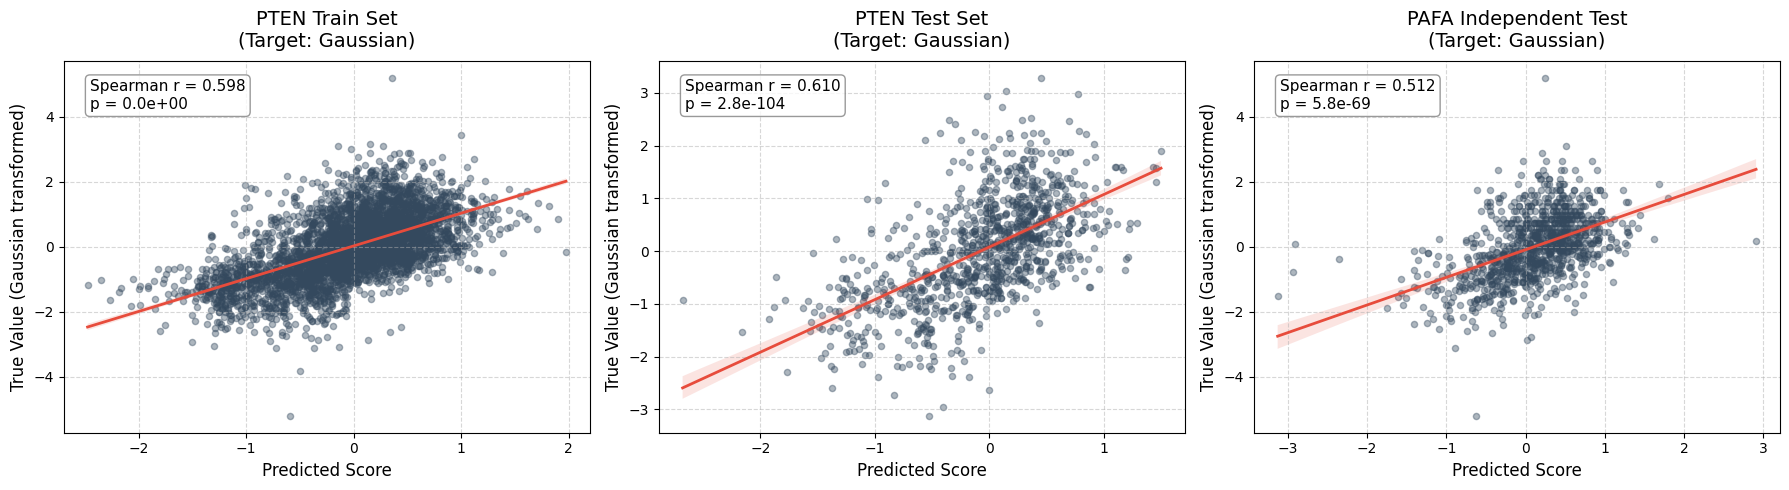


函数参数 (Parameters P):
g(d) [MPNN]  : A=-0.255, lambda=0.078, B=-0.061, omega=0.853
f(d) [DCA]   : A=-0.657, lambda=0.034, B=0.059, omega=0.460
v(d) [FoldX] : A=-11.071, lambda=0.000, B=0.105, omega=0.437, phi=0.359, C=10.853
Bias         : 0.039


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from scipy.optimize import least_squares
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

PTEN_CSV_PATH = "/share/home/wangtb/enzyme_shell/data/activity/3_PTEN.csv"
PAFA_CSV_PATH = "/share/home/wangtb/enzyme_shell/data/activity/3_PAFA.csv"

SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

df_pten = pd.read_csv(PTEN_CSV_PATH).dropna(subset=SCORES + ['Distance_to_Active_Site', 'Cum_score'])
df_pten = filter_single_mutations(df_pten)
for col in SCORES + ['Distance_to_Active_Site', 'Cum_score']:
    df_pten[col] = df_pten[col].astype(float)

pten_train, pten_test = train_test_split(df_pten, test_size=0.2, random_state=42)

print("正在加载 PAFA 独立测试集数据...")
df_pafa_raw = pd.read_csv(PAFA_CSV_PATH)
df_pafa_raw = df_pafa_raw[df_pafa_raw['kcat'] > 0]
df_pafa_raw['lg_kcat'] = np.log10(df_pafa_raw['kcat'])
df_pafa = df_pafa_raw.dropna(subset=SCORES + ['Distance_to_Active_Site', 'lg_kcat'])
df_pafa = filter_single_mutations(df_pafa)
for col in SCORES + ['Distance_to_Active_Site', 'lg_kcat']:
    df_pafa[col] = df_pafa[col].astype(float)

# 使用 QuantileTransformer 将特征转化为高斯分布
qt_X = QuantileTransformer(output_distribution='normal', random_state=42)
X_train = qt_X.fit_transform(pten_train[SCORES])
X_test  = qt_X.transform(pten_test[SCORES])
X_pafa  = qt_X.transform(df_pafa[SCORES])

d_train = pten_train['Distance_to_Active_Site'].values
d_test  = pten_test['Distance_to_Active_Site'].values
d_pafa  = df_pafa['Distance_to_Active_Site'].values

# 将目标变量 y 也转化为高斯分布，消除量纲和极端分布差异
qt_y_pten = QuantileTransformer(output_distribution='normal', random_state=42)
y_train = qt_y_pten.fit_transform(pten_train[['Cum_score']]).ravel()
y_test  = qt_y_pten.transform(pten_test[['Cum_score']]).ravel()

qt_y_pafa = QuantileTransformer(output_distribution='normal', random_state=42)
y_pafa  = qt_y_pafa.fit_transform(df_pafa[['lg_kcat']]).ravel()
# ----------------------------------------------

# Score = g(d)*MPNN + f(d)*DCA + v(d)*FoldX + Bias
def predict_score(P, d, X):
    X_mpnn = X[:, 0]
    X_dca  = X[:, 1]
    X_foldx= X[:, 2]
    
    g_d = P[0] * np.exp(-np.abs(P[1]) * d) + P[2] * np.cos(P[3] * d)
    f_d = P[4] * np.exp(-np.abs(P[5]) * d) + P[6] * np.cos(P[7] * d)
    v_d = P[8] * np.exp(-np.abs(P[9]) * d) + P[10] * np.sin(P[11] * d + P[12]) + P[13]
    
    y_pred = g_d * X_mpnn + f_d * X_dca + v_d * X_foldx + P[14]
    return y_pred

def objective_function(P, d, X, y_true):
    y_pred = predict_score(P, d, X)
    return y_pred - y_true

P0 = np.array([
    0.5, 0.1, 0.1, 1.0,  
    0.8, 0.05, 0.1, 0.5, 
    0.0, 0.0, 0.2, 0.3, 0.0, 0.0, 
    0.0                  
])

result = least_squares(objective_function, P0, args=(d_train, X_train, y_train), loss='soft_l1')
P_opt = result.x

y_pred_train = predict_score(P_opt, d_train, X_train)
y_pred_test  = predict_score(P_opt, d_test, X_test)
y_pred_pafa  = predict_score(P_opt, d_pafa, X_pafa)

r_train, p_train = spearmanr(y_train, y_pred_train)
r_test, p_test   = spearmanr(y_test, y_pred_test)
r_pafa, p_pafa   = spearmanr(y_pafa, y_pred_pafa)

print(f"PTEN 训练集 (Gaussian Cum_score) : r = {r_train:+.4f}, p = {p_train:.2e}")
print(f"PTEN 测试集 (Gaussian Cum_score) : r = {r_test:+.4f},  p = {p_test:.2e}")
print(f"PAFA 独立测试集 (Gaussian lg_kcat) : r = {r_pafa:+.4f},  p = {p_pafa:.2e}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    (y_train, y_pred_train, 'PTEN Train Set\n(Target: Gaussian)', r_train, p_train),
    (y_test, y_pred_test, 'PTEN Test Set\n(Target: Gaussian)', r_test, p_test),
    (y_pafa, y_pred_pafa, 'PAFA Independent Test\n(Target: Gaussian)', r_pafa, p_pafa)
]

for ax, (y_true, y_pred, title, r, p) in zip(axes, datasets):
    sns.regplot(
        x=y_pred, y=y_true, ax=ax, 
        scatter_kws={'alpha':0.4, 's':20, 'color':'#34495e'}, 
        line_kws={'color':'#e74c3c', 'linewidth':2}
    )
    ax.set_title(title, fontsize=14, pad=10)
    ax.set_xlabel('Predicted Score', fontsize=12)
    ax.set_ylabel('True Value (Gaussian transformed)', fontsize=12)
    ax.grid(linestyle='--', alpha=0.5)
    
    textstr = f'Spearman r = {r:.3f}\np = {p:.1e}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
    ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("\n函数参数 (Parameters P):")
print(f"g(d) [MPNN]  : A={P_opt[0]:.3f}, lambda={np.abs(P_opt[1]):.3f}, B={P_opt[2]:.3f}, omega={P_opt[3]:.3f}")
print(f"f(d) [DCA]   : A={P_opt[4]:.3f}, lambda={np.abs(P_opt[5]):.3f}, B={P_opt[6]:.3f}, omega={P_opt[7]:.3f}")
print(f"v(d) [FoldX] : A={P_opt[8]:.3f}, lambda={np.abs(P_opt[9]):.3f}, B={P_opt[10]:.3f}, omega={P_opt[11]:.3f}, phi={P_opt[12]:.3f}, C={P_opt[13]:.3f}")
print(f"Bias         : {P_opt[14]:.3f}")

正在基于原始分布训练 PTEN 模型...


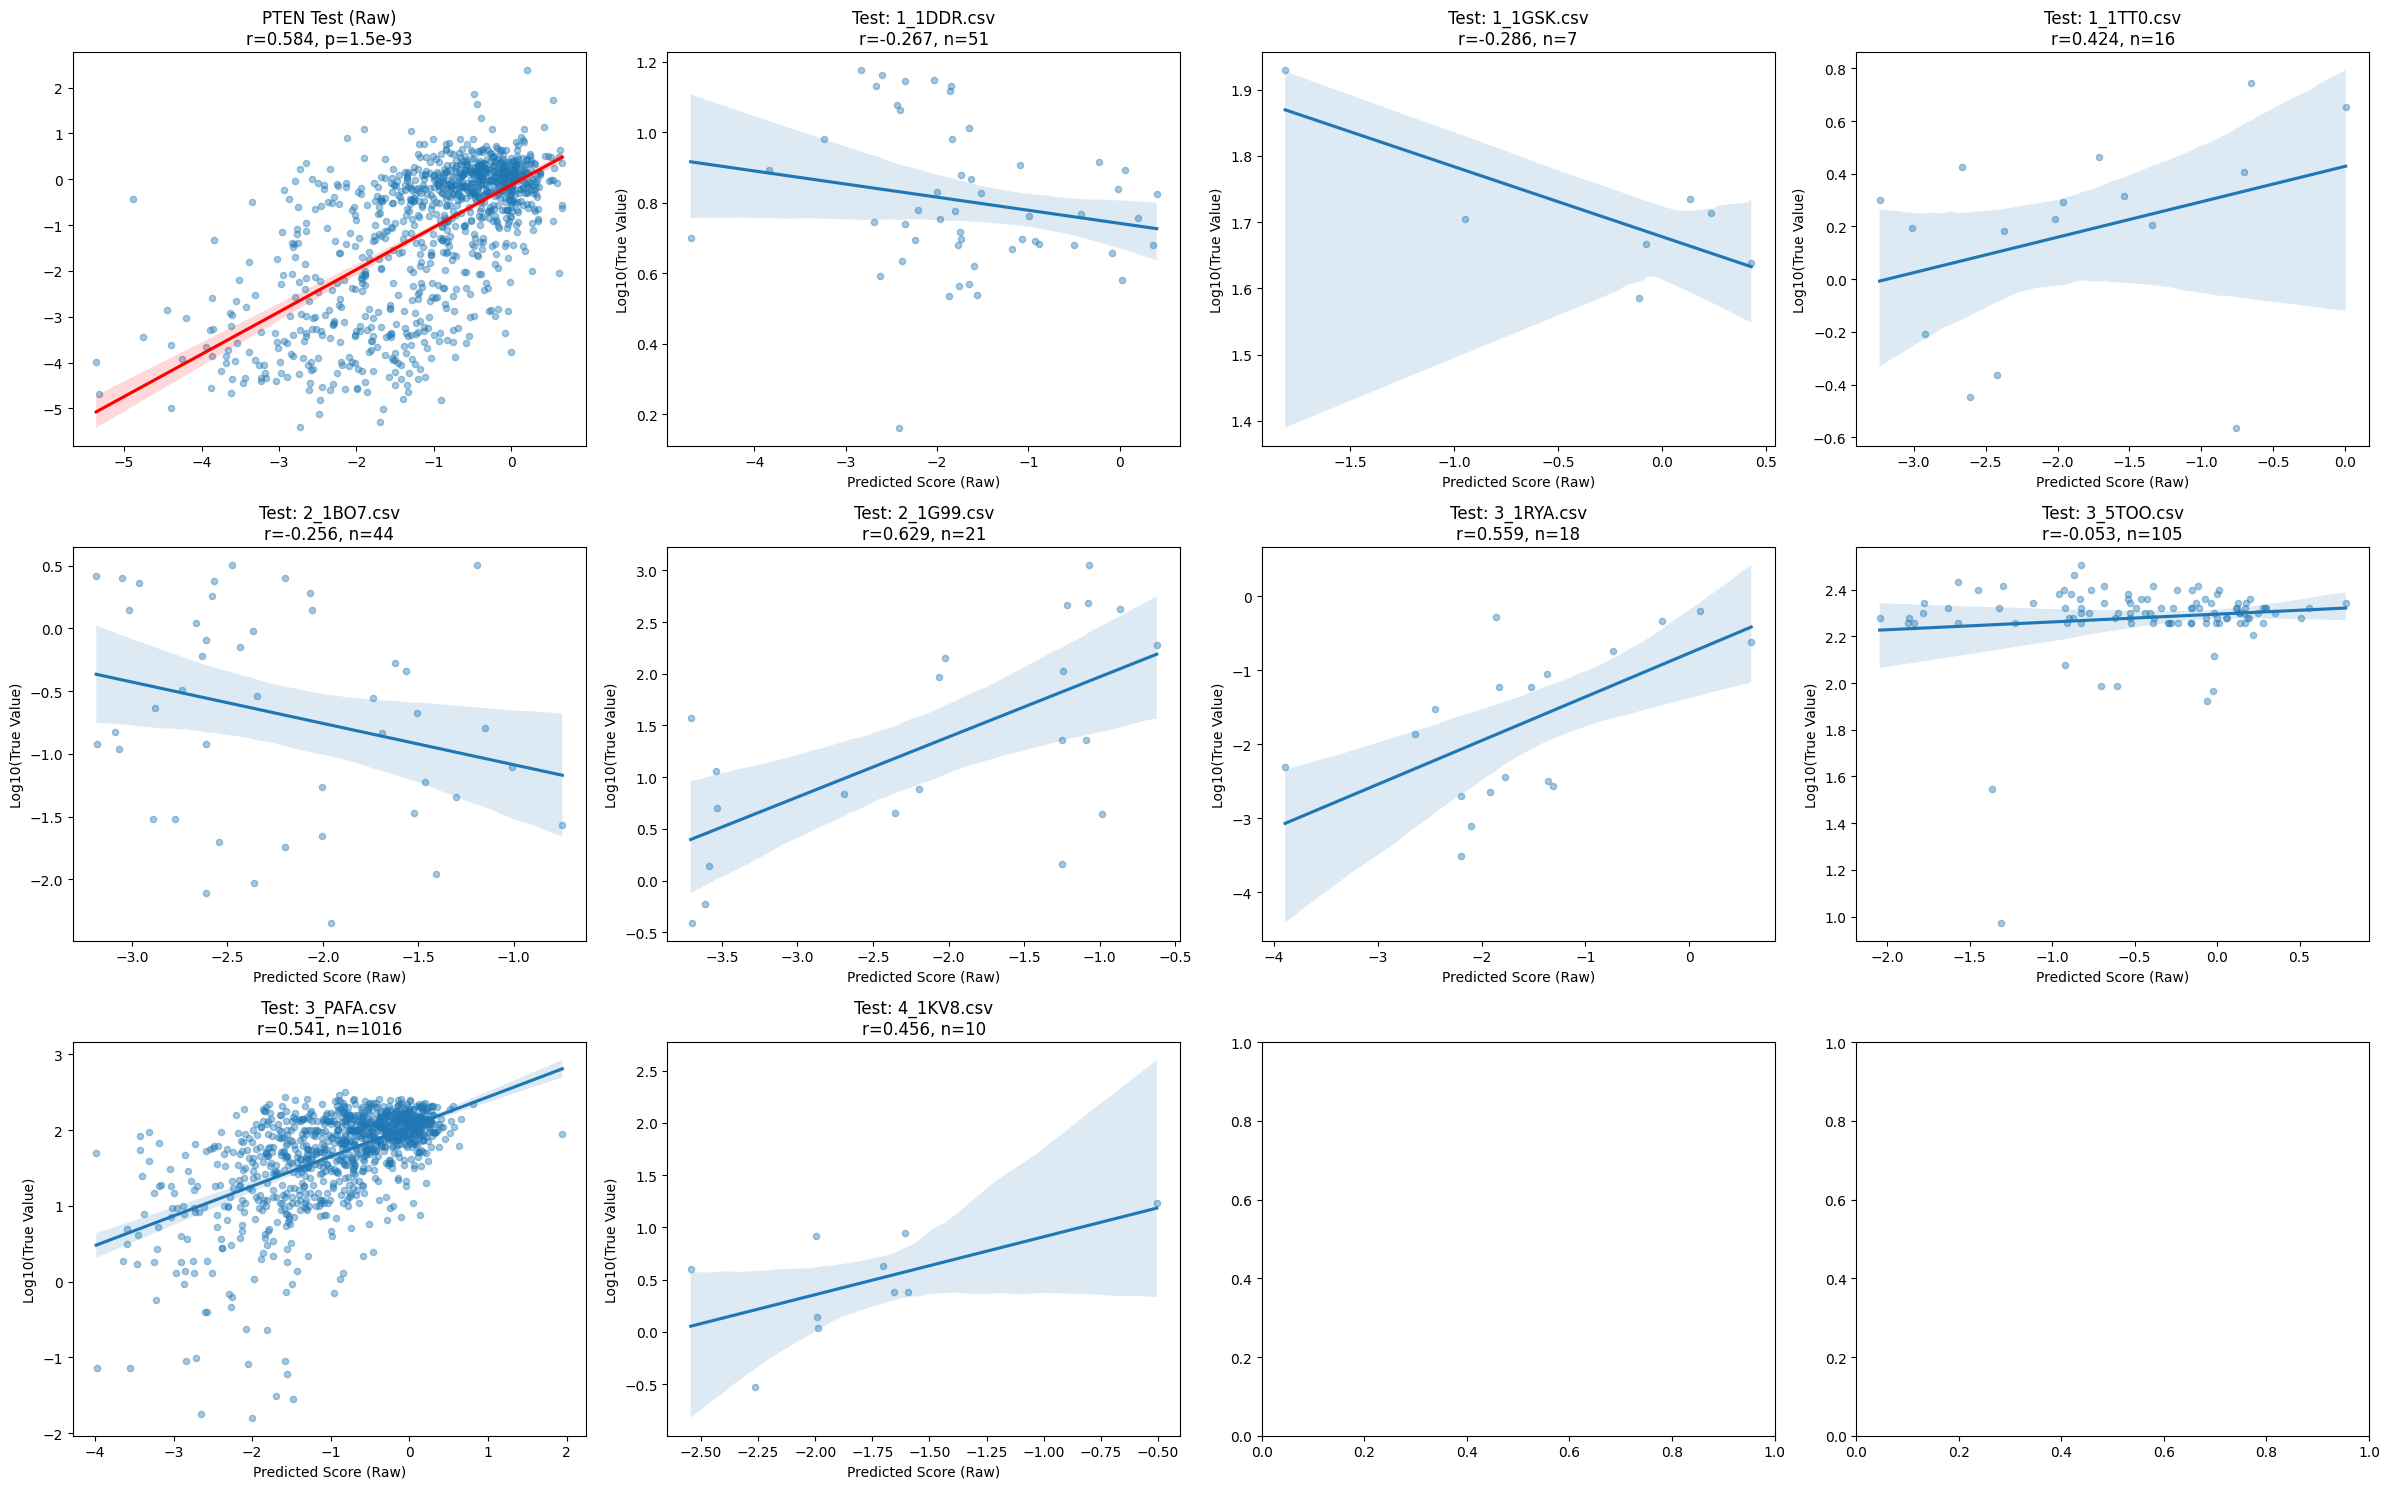

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from scipy.optimize import least_squares
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

# ================= 配置路径 =================
DATA_DIR = "/share/home/wangtb/enzyme_shell/data/activity"
PTEN_CSV_PATH = os.path.join(DATA_DIR, "3_PTEN.csv")

TEST_FILES = [
    "1_1DDR.csv", "1_1GSK.csv", "1_1TT0.csv", "2_1BO7.csv", 
    "2_1G99.csv", "3_1RYA.csv", "3_5TOO.csv", "3_PAFA.csv", "4_1KV8.csv"
]

SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']

# ================= 辅助工具函数 =================

def filter_single_mutations(df):
    if 'mutant' in df.columns:
        mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

def parse_multi_value(val):
    if pd.isna(val): return []
    s_val = str(val)
    if '/' in s_val:
        return [float(x) for x in s_val.split('/') if x.strip()]
    else:
        try: return [float(s_val)]
        except ValueError: return []

def predict_score(P, d, X_mpnn, X_dca, X_foldx):
    # 物理模型公式
    g_d = P[0] * np.exp(-np.abs(P[1]) * d) + P[2] * np.cos(P[3] * d)
    f_d = P[4] * np.exp(-np.abs(P[5]) * d) + P[6] * np.cos(P[7] * d)
    v_d = P[8] * np.exp(-np.abs(P[9]) * d) + P[10] * np.sin(P[11] * d + P[12]) + P[13]
    
    y_pred = g_d * X_mpnn + f_d * X_dca + v_d * X_foldx + P[14]
    return y_pred

def objective_function(P, d, X, y_true):
    y_pred = predict_score(P, d, X[:, 0], X[:, 1], X[:, 2])
    return y_pred - y_true

# ================= 数据准备与模型拟合 (原始分布) =================

print("正在基于原始分布训练 PTEN 模型...")
df_pten = pd.read_csv(PTEN_CSV_PATH).dropna(subset=SCORES + ['Distance_to_Active_Site', 'Cum_score'])
df_pten_single = filter_single_mutations(df_pten)

pten_train, pten_test = train_test_split(df_pten_single, test_size=0.2, random_state=42)

# 直接使用原始值
X_train = pten_train[SCORES].values
y_train = pten_train['Cum_score'].values
d_train = pten_train['Distance_to_Active_Site'].values

# 初始参数 (针对原始量纲微调)
P0 = np.zeros(15)
P0[0], P0[4], P0[8] = 0.1, 0.1, 0.1 # 初始权重

result = least_squares(objective_function, P0, args=(d_train, X_train, y_train), loss='soft_l1')
P_opt = result.x

# ================= 独立测试集处理函数 (原始分布) =================

def process_test_file_raw(file_path, P):
    if not os.path.exists(file_path): return None, None
        
    df = pd.read_csv(file_path)
    target_col = 'kcat' if 'kcat' in df.columns else 'value'
    
    # 清洗数据
    cols_to_check = SCORES + ['Distance_to_Active_Site', target_col]
    df = df.dropna(subset=[c for c in cols_to_check if c in df.columns])
    df = df[df[target_col] > 0].copy()
    df = filter_single_mutations(df)
    
    if df.empty or len(df) < 3: return None, None

    # 目标值：仅取 log10，不再进行 Gaussian 转换
    y_true_raw = np.log10(df[target_col]).values
    
    final_preds = []
    for _, row in df.iterrows():
        mpnns = parse_multi_value(row['LigandMPNN_score'])
        dcas = parse_multi_value(row['DCA_score'])
        dists = parse_multi_value(row['Distance_to_Active_Site'])
        foldx = float(row['FoldX_ddG'])
        
        n_mut = min(len(mpnns), len(dcas), len(dists))
        if n_mut == 0:
            final_preds.append(np.nan)
            continue
        
        row_preds = []
        for i in range(n_mut):
            # 直接传入原始特征
            p = predict_score(P, dists[i], mpnns[i], dcas[i], foldx)
            row_preds.append(p)
        final_preds.append(np.mean(row_preds))
        
    y_pred = np.array(final_preds)
    mask = ~np.isnan(y_pred)
    return y_true_raw[mask], y_pred[mask]

# ================= 绘图与展示 =================

fig, axes = plt.subplots(3, 4, figsize=(24, 15))
axes = axes.flatten()

# 1. PTEN 测试集 (原始尺度)
X_test = pten_test[SCORES].values
y_test = pten_test['Cum_score'].values
d_test = pten_test['Distance_to_Active_Site'].values
y_pred_pten = predict_score(P_opt, d_test, X_test[:,0], X_test[:,1], X_test[:,2])

r_pten, p_pten = spearmanr(y_test, y_pred_pten)
sns.regplot(x=y_pred_pten, y=y_test, ax=axes[0], scatter_kws={'alpha':0.4, 's':20}, line_kws={'color':'red'})
axes[0].set_title(f"PTEN Test (Raw)\nr={r_pten:.3f}, p={p_pten:.1e}")

# 2. 独立测试集 (原始尺度)
for i, file_name in enumerate(TEST_FILES):
    ax_idx = i + 1
    path = os.path.join(DATA_DIR, file_name)
    y_true, y_pred = process_test_file_raw(path, P_opt)
    
    if y_true is not None:
        r, p = spearmanr(y_true, y_pred)
        display_title = f"Test: {file_name}\nr={r:.3f}, n={len(y_true)}"
        sns.regplot(x=y_pred, y=y_true, ax=axes[ax_idx], scatter_kws={'alpha':0.4, 's':20})
    else:
        display_title = f"Test: {file_name}\n(Insufficient Data)"
    
    axes[ax_idx].set_title(display_title)
    axes[ax_idx].set_xlabel('Predicted Score (Raw)')
    axes[ax_idx].set_ylabel('Log10(True Value)')

plt.tight_layout()
plt.show()

正在训练 PTEN 基准模型 (基于单突变)...


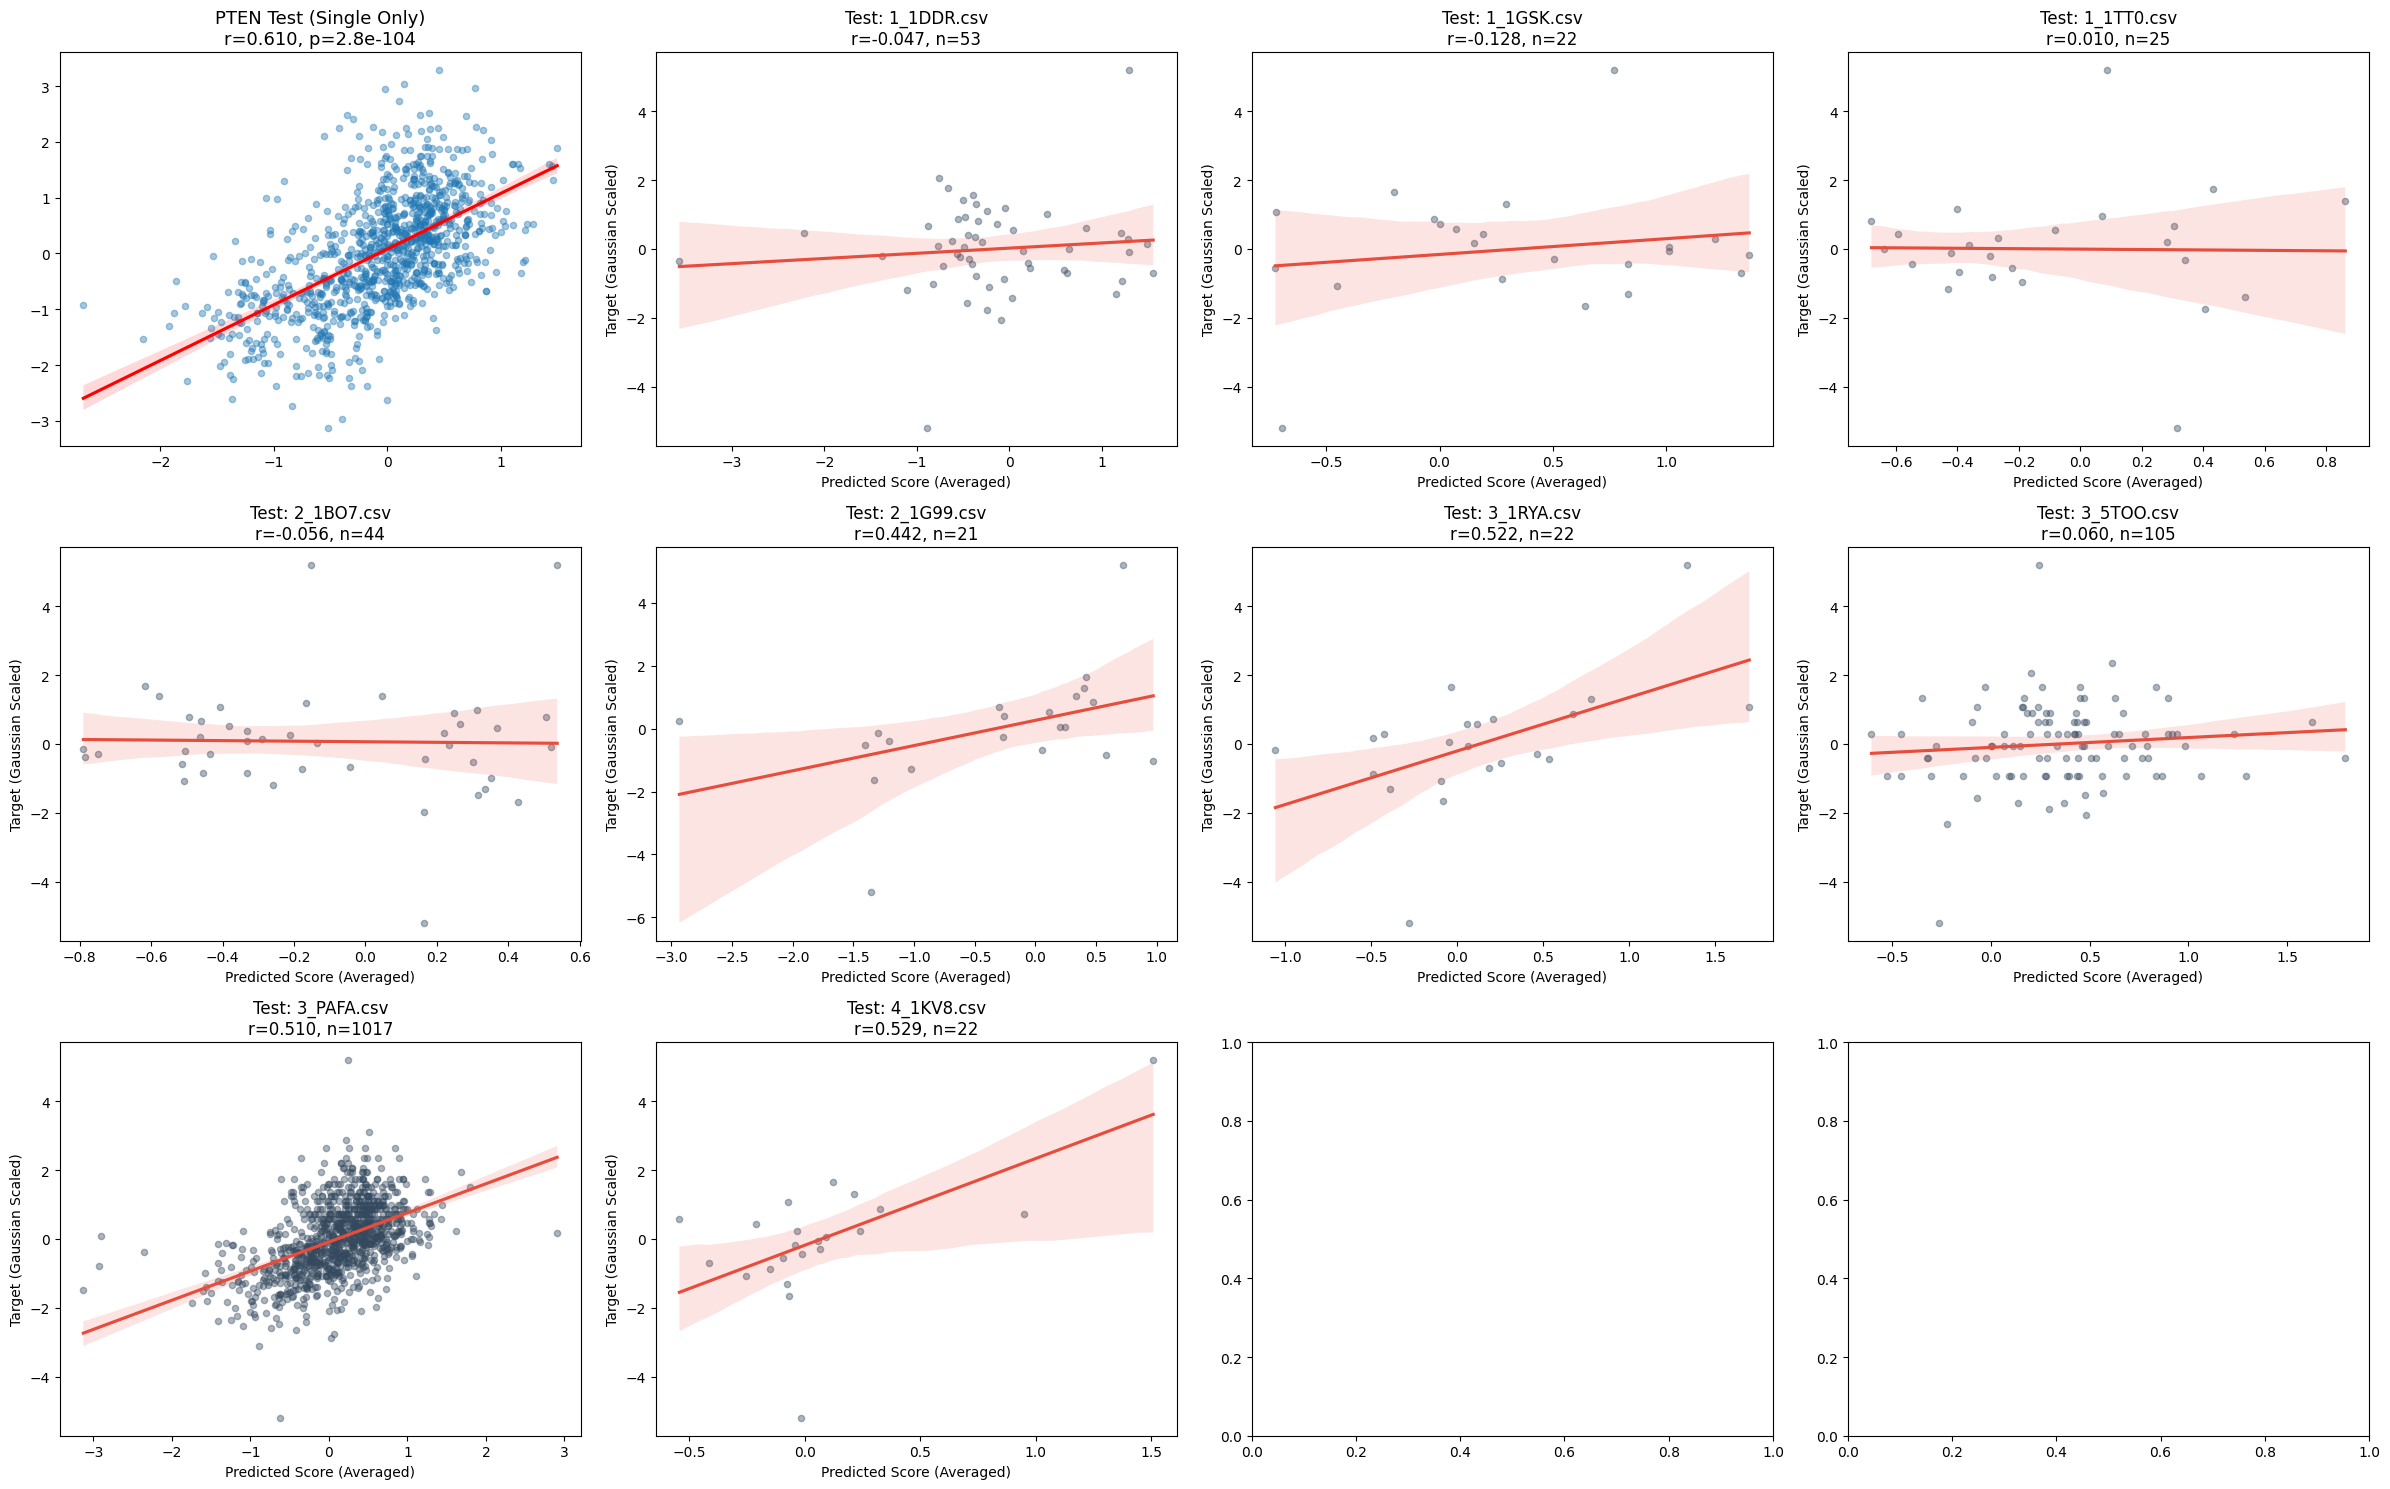


优化后的函数参数 (Parameters P):
------------------------------------------------------------
g(d) [MPNN]  : A=-0.255, lambda=0.078, B=-0.061, omega=0.853
f(d) [DCA]   : A=-0.657, lambda=0.034, B=0.059, omega=0.460
v(d) [FoldX] : A=-11.071, lambda=0.000, B=0.105, omega=0.437, phi=0.359, C=10.853
Bias         : 0.039


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer
from scipy.optimize import least_squares
from scipy.stats import spearmanr

import warnings
warnings.filterwarnings('ignore')

# ================= 配置路径 =================
DATA_DIR = "/share/home/wangtb/enzyme_shell/data/activity"
PTEN_CSV_PATH = os.path.join(DATA_DIR, "3_PTEN.csv")

# 待处理的 9 个测试文件
TEST_FILES = [
    "1_1DDR.csv", "1_1GSK.csv", "1_1TT0.csv", "2_1BO7.csv", 
    "2_1G99.csv", "3_1RYA.csv", "3_5TOO.csv", "3_PAFA.csv", "4_1KV8.csv"
]

SCORES = ['LigandMPNN_score', 'DCA_score', 'FoldX_ddG']

# ================= 辅助工具函数 =================

def filter_mutants(df, allow_multi=False):
    """
    提取突变行。
    allow_multi=False: 仅单突变 (A123B)
    allow_multi=True: 允许单突变及多突变 (A123B/C124D)
    """
    if 'mutant' in df.columns:
        if allow_multi:
            # 匹配单突变或由/分隔的多突变
            mask = df['mutant'].astype(str).str.match(r'^([A-Za-z]\s*\d+\s*[A-Za-z])(/[A-Za-z]\s*\d+\s*[A-Za-z])*$', na=False)
        else:
            mask = df['mutant'].astype(str).str.match(r'^[A-Za-z]\s*\d+\s*[A-Za-z]$', na=False)
        return df[mask].copy()
    return df

def parse_multi_value(val):
    """解析 float 或带 '/' 的字符串为 list"""
    if pd.isna(val) or str(val).strip() == "":
        return []
    s_val = str(val)
    if '/' in s_val:
        parts = s_val.split('/')
        res = []
        for x in parts:
            try:
                res.append(float(x.strip()))
            except ValueError:
                continue
        return res
    else:
        try:
            return [float(s_val)]
        except ValueError:
            return []

def predict_score(P, d, X_mpnn, X_dca, X_foldx):
    """核心物理/数学预测模型"""
    # g(d) = P0 * exp(-|P1|*d) + P2 * cos(P3*d)
    g_d = P[0] * np.exp(-np.abs(P[1]) * d) + P[2] * np.cos(P[3] * d)
    # f(d) = P4 * exp(-|P5|*d) + P6 * cos(P7*d)
    f_d = P[4] * np.exp(-np.abs(P[5]) * d) + P[6] * np.cos(P[7] * d)
    # v(d) = P8 * exp(-|P9|*d) + P10 * sin(P11*d + P12) + P13
    v_d = P[8] * np.exp(-np.abs(P[9]) * d) + P[10] * np.sin(P[11] * d + P[12]) + P[13]
    
    y_pred = g_d * X_mpnn + f_d * X_dca + v_d * X_foldx + P[14]
    return y_pred

def objective_function(P, d, X, y_true):
    """优化目标：残差平方和"""
    y_pred = predict_score(P, d, X[:, 0], X[:, 1], X[:, 2])
    return y_pred - y_true

# ================= 数据准备与模型拟合 (基于 PTEN 单突变) =================

print("正在训练 PTEN 基准模型 (基于单突变)...")
df_pten = pd.read_csv(PTEN_CSV_PATH).dropna(subset=SCORES + ['Distance_to_Active_Site', 'Cum_score'])
df_pten_single = filter_mutants(df_pten, allow_multi=False)

qt_X = QuantileTransformer(output_distribution='normal', random_state=42)
qt_y = QuantileTransformer(output_distribution='normal', random_state=42)

pten_train, pten_test = train_test_split(df_pten_single, test_size=0.2, random_state=42)

X_train_scaled = qt_X.fit_transform(pten_train[SCORES])
y_train_scaled = qt_y.fit_transform(pten_train[['Cum_score']]).ravel()
d_train = pten_train['Distance_to_Active_Site'].values

P0 = np.array([0.5, 0.1, 0.1, 1.0, 0.8, 0.05, 0.1, 0.5, 0.0, 0.0, 0.2, 0.3, 0.0, 0.0, 0.0])
result = least_squares(objective_function, P0, args=(d_train, X_train_scaled, y_train_scaled), loss='soft_l1')
P_opt = result.x

# ================= 独立测试集处理函数 (支持多突变取平均) =================

def process_test_file(file_path, P, qt_X):
    """处理独立测试文件，支持多突变解析与平均预测"""
    if not os.path.exists(file_path):
        return None, None
        
    df = pd.read_csv(file_path)
    target_col = 'kcat' if 'kcat' in df.columns else 'value'
    
    # 基础清洗
    df = df.dropna(subset=[c for c in [target_col, 'mutant'] if c in df.columns])
    df = df[df[target_col] > 0].copy()
    
    # 允许包含多突变
    df = filter_mutants(df, allow_multi=True)
    
    if df.empty or len(df) < 2:
        return None, None

    # 目标值局部高斯转换
    df['lg_target'] = np.log10(df[target_col])
    qt_y_local = QuantileTransformer(output_distribution='normal', random_state=42)
    y_true_scaled = qt_y_local.fit_transform(df[['lg_target']]).ravel()
    
    final_preds = []
    
    for _, row in df.iterrows():
        # 解析各列的多值
        mpnns = parse_multi_value(row.get('LigandMPNN_score'))
        dcas = parse_multi_value(row.get('DCA_score'))
        dists = parse_multi_value(row.get('Distance_to_Active_Site'))
        foldxs = parse_multi_value(row.get('FoldX_ddG'))
        
        # 确定突变个数 (以 MPNN 或 DCA 或 Dist 的最大数量为准)
        n_mut = max(len(mpnns), len(dcas), len(dists))
        
        if n_mut == 0:
            final_preds.append(np.nan)
            continue
            
        row_sub_scores = []
        for j in range(n_mut):
            # 安全取值：如果该项只有1个值（如 FoldX），则所有子突变共用；否则对应索引取值
            m = mpnns[j] if j < len(mpnns) else (mpnns[0] if mpnns else 0)
            d = dcas[j] if j < len(dcas) else (dcas[0] if dcas else 0)
            dist = dists[j] if j < len(dists) else (dists[0] if dists else 0)
            f = foldxs[j] if j < len(foldxs) else (foldxs[0] if foldxs else 0)
            
            # 缩放特征 (QuantileTransformer 需要 2D 输入)
            feat = np.array([[m, d, f]])
            feat_scaled = qt_X.transform(feat)[0]
            
            # 单个突变预测
            p_sub = predict_score(P, dist, feat_scaled[0], feat_scaled[1], feat_scaled[2])
            row_sub_scores.append(p_sub)
            
        # 对该突变体的所有子突变预测值取平均
        final_preds.append(np.mean(row_sub_scores))
        
    y_pred = np.array(final_preds)
    
    # 剔除无效预测
    valid_mask = ~np.isnan(y_pred)
    if not any(valid_mask):
        return None, None
        
    return y_true_scaled[valid_mask], y_pred[valid_mask]

# ================= 绘图与结果展示 =================

fig, axes = plt.subplots(3, 4, figsize=(24, 15))
axes = axes.flatten()

# 1. 绘制 PTEN 测试集 (基准)
X_test_scaled = qt_X.transform(pten_test[SCORES])
y_test_scaled = qt_y.transform(pten_test[['Cum_score']]).ravel()
y_pred_pten = predict_score(P_opt, pten_test['Distance_to_Active_Site'].values, 
                            X_test_scaled[:,0], X_test_scaled[:,1], X_test_scaled[:,2])

r_pten, p_pten = spearmanr(y_test_scaled, y_pred_pten)
sns.regplot(x=y_pred_pten, y=y_test_scaled, ax=axes[0], 
            scatter_kws={'alpha':0.4, 's':20}, line_kws={'color':'red'})
axes[0].set_title(f"PTEN Test (Single Only)\nr={r_pten:.3f}, p={p_pten:.1e}", fontsize=13)

# 2. 循环处理测试文件 (包含多突变平均逻辑)
for i, file_name in enumerate(TEST_FILES):
    ax_idx = i + 1
    path = os.path.join(DATA_DIR, file_name)
    
    y_true, y_pred = process_test_file(path, P_opt, qt_X)
    
    if y_true is not None and len(y_true) > 2:
        r, p = spearmanr(y_true, y_pred)
        display_title = f"Test: {file_name}\nr={r:.3f}, n={len(y_true)}"
        
        sns.regplot(x=y_pred, y=y_true, ax=axes[ax_idx], 
                    scatter_kws={'alpha':0.4, 's':20, 'color':'#34495e'}, 
                    line_kws={'color':'#e74c3c'})
    else:
        display_title = f"Test: {file_name}\n(Insufficient Data)"
    
    axes[ax_idx].set_title(display_title, fontsize=12)
    axes[ax_idx].set_xlabel('Predicted Score (Averaged)')
    axes[ax_idx].set_ylabel('Target (Gaussian Scaled)')

plt.tight_layout()
plt.show()

# 输出优化参数
print("\n优化后的函数参数 (Parameters P):")
print("-" * 60)
print(f"g(d) [MPNN]  : A={P_opt[0]:.3f}, lambda={np.abs(P_opt[1]):.3f}, B={P_opt[2]:.3f}, omega={P_opt[3]:.3f}")
print(f"f(d) [DCA]   : A={P_opt[4]:.3f}, lambda={np.abs(P_opt[5]):.3f}, B={P_opt[6]:.3f}, omega={P_opt[7]:.3f}")
print(f"v(d) [FoldX] : A={P_opt[8]:.3f}, lambda={np.abs(P_opt[9]):.3f}, B={P_opt[10]:.3f}, omega={P_opt[11]:.3f}, phi={P_opt[12]:.3f}, C={P_opt[13]:.3f}")
print(f"Bias         : {P_opt[14]:.3f}")